In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(color_codes=True)

from google.colab import drive
from sklearn.model_selection import train_test_split
import math
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path='/content/drive/MyDrive/Clean_Dataset.csv'
df=pd.read_csv(file_path)
print(df)

        Unnamed: 0   airline   flight source_city departure_time stops  \
0                0  SpiceJet  SG-8709       Delhi        Evening  zero   
1                1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2                2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3                3   Vistara   UK-995       Delhi        Morning  zero   
4                4   Vistara   UK-963       Delhi        Morning  zero   
...            ...       ...      ...         ...            ...   ...   
300148      300148   Vistara   UK-822     Chennai        Morning   one   
300149      300149   Vistara   UK-826     Chennai      Afternoon   one   
300150      300150   Vistara   UK-832     Chennai  Early_Morning   one   
300151      300151   Vistara   UK-828     Chennai  Early_Morning   one   
300152      300152   Vistara   UK-822     Chennai        Morning   one   

         arrival_time destination_city     class  duration  days_left  price  
0               Night           

In [ ]:
df2=df.drop(columns=['Unnamed: 0','flight'])
df2

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
df2.dtypes

,0
airline,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64
days_left,int64
price,int64


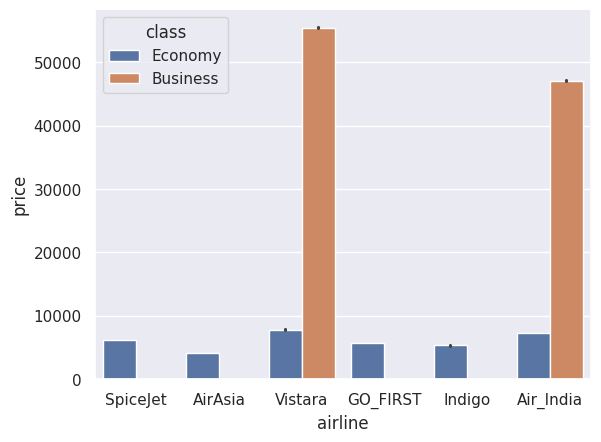

In [ ]:
sns.barplot(data=df2,x='airline',y='price',hue='class')
plt.show()

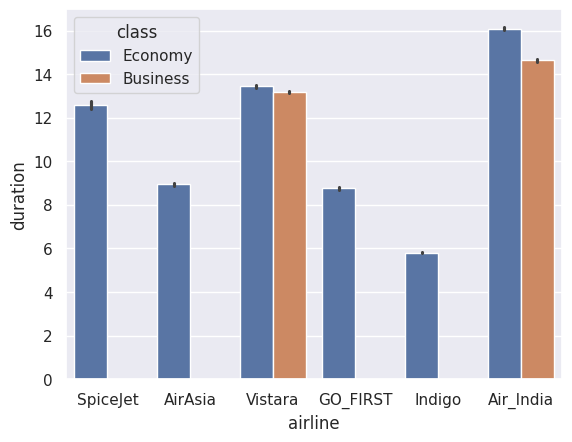

In [ ]:
sns.barplot(data=df2,x='airline',y='duration',hue='class')
plt.show()

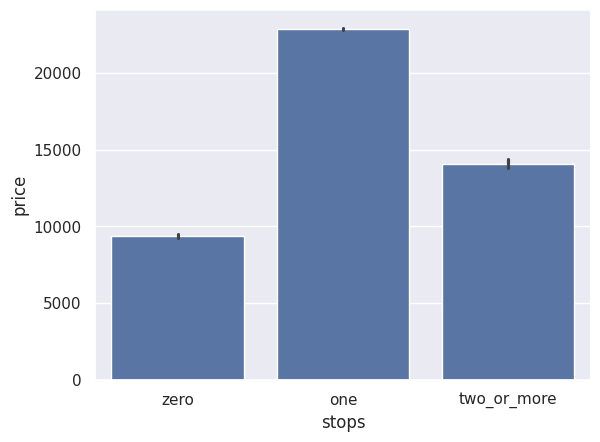

In [ ]:
sns.barplot(data=df2,x='stops',y='price')
plt.show()

<Axes: xlabel='stops', ylabel='count'>

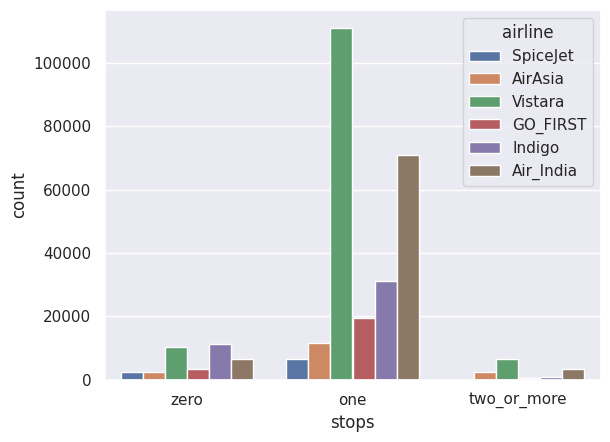

In [ ]:
sns.countplot(data=df,x='stops',hue='airline')

<Axes: xlabel='destination_city', ylabel='price'>

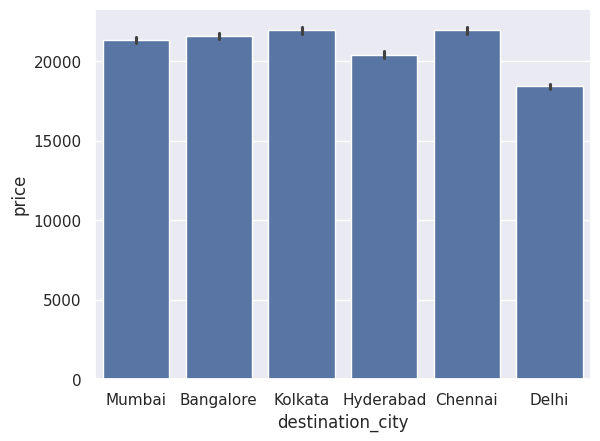

In [ ]:
sns.barplot(data=df2,x='destination_city',y='price')

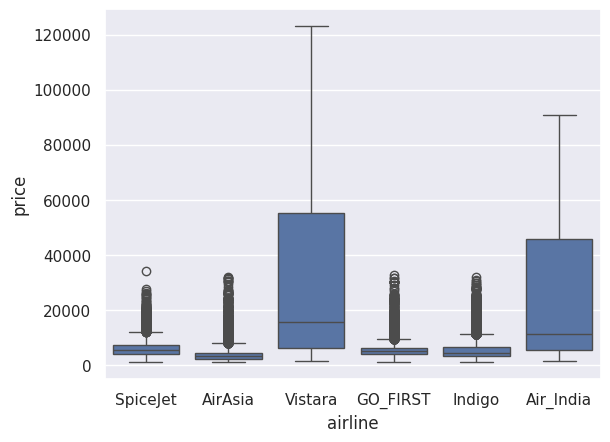

In [ ]:
sns.boxplot(data=df2,x='airline',y='price')
plt.show()

Data preprocessing


In [ ]:
df['source_city'].unique()

array(['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai'],
      dtype=object)

In [ ]:
df['departure_time'].unique()

array(['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night',
       'Late_Night'], dtype=object)

In [ ]:
df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [ ]:
df['arrival_time'].unique()

array(['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening',
       'Late_Night'], dtype=object)

In [ ]:
df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [ ]:
df['class'].unique()

array(['Economy', 'Business'], dtype=object)

In [ ]:
df['destination_city'].unique()

array(['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi'],
      dtype=object)

In [ ]:
df['days_left'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [ ]:
df2['departure_time']=df2['departure_time'].replace({'Evening':0,'Early_Morning':1,'Morning':2,'Afternoon':3,'Night':4,'Late_Night':5})
df2['departure_time']
df2['arrival_time']=df2['arrival_time'].replace({'Evening':0,'Early_Morning':1,'Morning':2,'Afternoon':3,'Night':4,'Late_Night':5})
df2['arrival_time']
df2['stops']=df2['stops'].replace({'zero':0,'one':1,'two_or_more':2})
df2['stops']
df2['destination_city']=df2['destination_city'].replace({'Mumbai':0, 'Bangalore':1, 'Kolkata':2, 'Hyderabad':3, 'Chennai':4, 'Delhi':5})
df2['destination_city']
df2['class']=df2['class'].replace({'Economy':0,'Business':1})
df2['class']
df2['airline']=df2['airline'].replace({'SpiceJet':0,'AirAsia':1,'Vistara':2,'GO_FIRST':3,'Indigo':4,'Air_India':5})
df2['airline']
df2['source_city']=df2['source_city'].replace({'Delhi':0,'Mumbai':1,'Bangalore':2,'Kolkata':3,'Hyderabad':4,'Chennai':5})
df2['source_city']

/tmp/ipykernel_3384/2187936271.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['departure_time']=df2['departure_time'].replace({'Evening':0,'Early_Morning':1,'Morning':2,'Afternoon':3,'Night':4,'Late_Night':5})
/tmp/ipykernel_3384/2187936271.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['arrival_time']=df2['arrival_time'].replace({'Evening':0,'Early_Morning':1,'Morning':2,'Afternoon':3,'Night':4,'Late_Night':5})
/tmp/ipykernel_3384/2187936271.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated an

,source_city
0,0
1,0
2,0
3,0
4,0
...,...
300148,5
300149,5
300150,5
300151,5


In [ ]:
df2['airline']=pd.to_numeric(df2['airline'])
df2['source_city']=pd.to_numeric(df2['source_city'])
df2['destination_city']=pd.to_numeric(df2['destination_city'])
df2['stops']=pd.to_numeric(df2['stops'])
df2['departure_time']=pd.to_numeric(df2['departure_time'])
df2['arrival_time']=pd.to_numeric(df2['arrival_time'])
df2['class']=pd.to_numeric(df2['class'])
df2['days_left']=pd.to_numeric(df2['days_left'])
df2['price']=pd.to_numeric(df2['price'])
df2['duration']=pd.to_numeric(df2['duration'])
df2.dtypes

,0
airline,int64
source_city,int64
departure_time,int64
stops,int64
arrival_time,int64
destination_city,int64
class,int64
duration,float64
days_left,int64
price,int64


<Axes: >

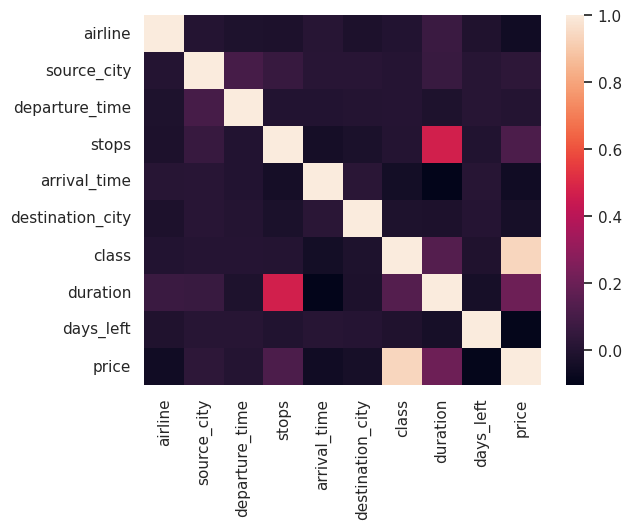

In [ ]:
sns.heatmap(df2.corr(),fmt=' .2g' )

In [ ]:
x=df2.drop(columns=['price'])
y=df2['price']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

ab= AdaBoostRegressor(random_state=0)
ab.fit(x_train,y_train)

AdaBoostRegressor(random_state=0)

In [ ]:
y_pred=ab.predict(x_test)
y_pred

array([ 5786.57661751, 68572.71329778,  5828.4080198 , ...,
        5786.57661751,  5532.7490726 , 70830.32458425])

In [ ]:
from sklearn import metrics
mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
r2=metrics.r2_score(y_test,y_pred)
rmse= math.sqrt(mse)
print('R2 score:',r2)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)

R2 score: 0.9223440350806018
Mean Absolute Error: 4120.646998611441
Mean Squared Error: 40030273.352836
Root Mean Squared Error: 6326.9481863562
